# Bài nộp: Phát hiện bất thường trên dữ liệu NAB

Dự án nhỏ phát hiện bất thường sử dụng bộ dữ liệu `realKnownCause/machine_temperature_system_failure.csv` từ NAB.

Các phần chính: nạp dữ liệu, EDA, chia train/validation/test để tránh data leakage, bộ phát hiện thống kê, Isolation Forest, tinh chỉnh tham số, đánh giá, vẽ kết quả và nhận xét ngắn.

## 1. Nạp dữ liệu NAB

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

ROOT = Path(".")
DATA_PATH = ROOT / "data" / "machine_temperature_system_failure.csv"


if not DATA_PATH.exists():
    ROOT = Path("w1/day-a")
    DATA_PATH = ROOT / "data" / "machine_temperature_system_failure.csv"


anomaly_timestamps = pd.to_datetime([
    "2013-12-11 06:00:00",
    "2013-12-16 17:25:00",
    "2014-01-28 13:55:00",
    "2014-02-08 14:30:00",
])

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
label_window = pd.Timedelta(hours=1)
df["label"] = 0
for ts in anomaly_timestamps:
    df.loc[(df["timestamp"] >= ts - label_window) & (df["timestamp"] <= ts + label_window), "label"] = 1

df.head()

,timestamp,value,label
0,2013-12-02 21:15:00,73.967322,0
1,2013-12-02 21:20:00,74.935882,0
2,2013-12-02 21:25:00,76.124162,0
3,2013-12-02 21:30:00,78.140707,0
4,2013-12-02 21:35:00,79.329836,0


## 2. EDA

In [2]:
df.describe()

,timestamp,value,label
count,22695,22695.000000,22695.000000
mean,2014-01-11 06:16:49.887640,85.926498,0.004406
min,2013-12-02 21:15:00,2.084721,0.000000
25%,2013-12-22 14:02:30,83.080078,0.000000
50%,2014-01-11 05:50:00,89.408246,0.000000
75%,2014-01-30 22:37:30,94.016252,0.000000
max,2014-02-19 15:25:00,108.510543,1.000000
std,NaN,13.746912,0.066235


In [3]:
eda_stats = pd.Series({
    "trung_binh": df["value"].mean(),
    "do_lech_chuan": df["value"].std(),
    "gia_tri_nho_nhat": df["value"].min(),
    "gia_tri_lon_nhat": df["value"].max(),
    "do_lech_phan_phoi_skewness": df["value"].skew(),
    "so_diem_label_anomaly": df["label"].sum(),
})
eda_stats

trung_binh                     85.926498
do_lech_chuan                  13.746912
gia_tri_nho_nhat                2.084721
gia_tri_lon_nhat              108.510543
do_lech_phan_phoi_skewness     -1.833807
so_diem_label_anomaly         100.000000
dtype: float64

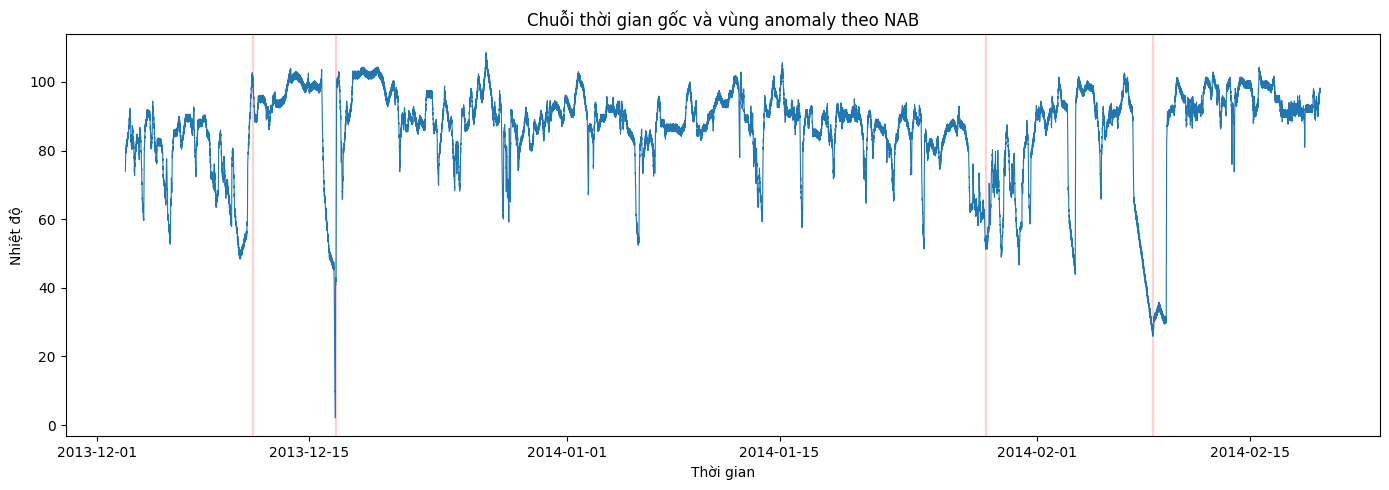

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["value"], linewidth=0.8)
for ts in anomaly_timestamps:
    plt.axvspan(ts - label_window, ts + label_window, color="red", alpha=0.12)
plt.title("Chuỗi thời gian gốc và vùng anomaly theo NAB")
plt.xlabel("Thời gian")
plt.ylabel("Nhiệt độ")
plt.tight_layout()
plt.show()

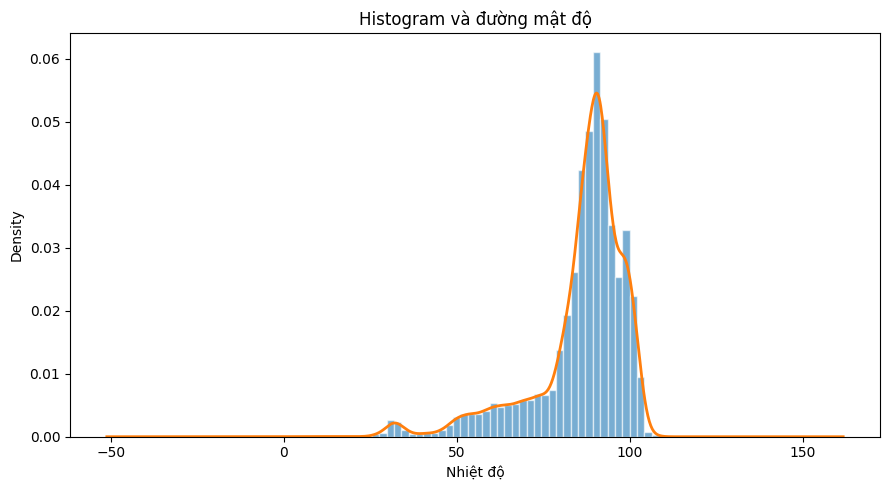

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(df["value"], bins=50, density=True, alpha=0.6, edgecolor="white")
df["value"].plot(kind="kde", linewidth=2)
plt.title("Histogram và đường mật độ")
plt.xlabel("Nhiệt độ")
plt.tight_layout()
plt.show()

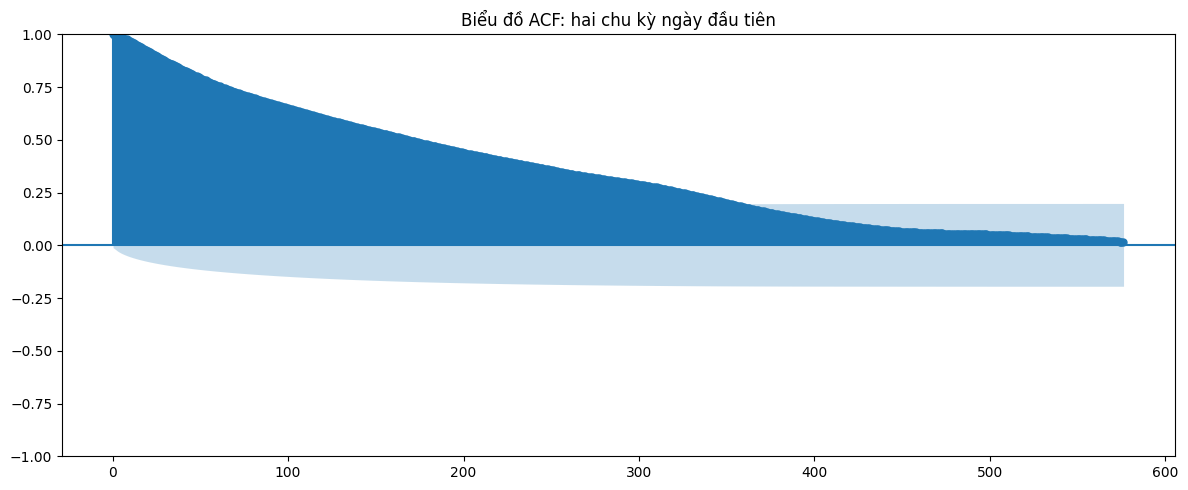

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(df["value"], lags=288 * 2, ax=ax)
ax.set_title("Biểu đồ ACF: hai chu kỳ ngày đầu tiên")
plt.tight_layout()
plt.show()

**Kết luận EDA**

- Skewness khoảng `-1.834`, nên phân phối bị lệch trái khá mạnh, không đối xứng.
- Biểu đồ ACF có các đỉnh lặp lại quanh lag 288. Vì dữ liệu lấy mẫu mỗi 5 phút, 288 lag tương ứng khoảng 1 ngày, nên dữ liệu có tính seasonal theo ngày.
- Chuỗi không hoàn toàn stationary vì mức trung bình và độ biến động thay đổi quanh các giai đoạn lỗi.
- Để tránh data leakage, không fit detector hoặc tune tham số trên toàn bộ dữ liệu. Bài này chia dữ liệu theo thời gian: train để fit, validation để tune, test để báo cáo kết quả cuối.
- Vì phân phối skew mạnh, detector thống kê được chọn là IQR fit trên train. Isolation Forest dùng nhiều đặc trưng theo ngữ cảnh để so sánh.

## 3. Chia dữ liệu để tránh data leakage

In [7]:
n = len(df)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

df["split"] = "test"
df.loc[:train_end - 1, "split"] = "train"
df.loc[train_end:val_end - 1, "split"] = "validation"

split_summary = df.groupby("split").agg(
    start=("timestamp", "min"),
    end=("timestamp", "max"),
    rows=("value", "size"),
    anomaly_points=("label", "sum"),
)
split_summary

,start,end,rows,anomaly_points
split,,,,
test,2014-02-03 21:15:00,2014-02-19 15:25:00,4539,25
train,2013-12-02 21:15:00,2014-01-19 02:55:00,13617,50
validation,2014-01-19 03:00:00,2014-02-03 21:10:00,4539,25


## 4. Bộ phát hiện thống kê

In [8]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

def evaluate(y_true, y_pred):
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "canh_bao_sai": int(((y_pred == 1) & (y_true == 0)).sum()),
    }

# Fit Q1/Q3/IQR trên train để tránh data leakage.
q1 = train_df["value"].quantile(0.25)
q3 = train_df["value"].quantile(0.75)
iqr = q3 - q1

# Tune hệ số IQR trên validation, không dùng test để chọn tham số.
iqr_results = []
best_iqr_f1 = -1
best_iqr_multiplier = None
for multiplier in [1.5, 2.0, 2.5, 3.0]:
    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr
    val_pred = ((val_df["value"] < lower_bound) | (val_df["value"] > upper_bound)).astype(int).to_numpy()
    metric = evaluate(val_df["label"].to_numpy(), val_pred)
    iqr_results.append({
        "he_so_IQR": multiplier,
        "Precision_validation": metric["Precision"],
        "Recall_validation": metric["Recall"],
        "F1_validation": metric["F1"],
        "Canh_bao_sai_validation": metric["canh_bao_sai"],
    })
    if metric["F1"] > best_iqr_f1:
        best_iqr_f1 = metric["F1"]
        best_iqr_multiplier = multiplier

lower_bound = q1 - best_iqr_multiplier * iqr
upper_bound = q3 + best_iqr_multiplier * iqr
df["stat_pred"] = ((df["value"] < lower_bound) | (df["value"] > upper_bound)).astype(int)

stat_metrics_test = evaluate(
    test_df["label"].to_numpy(),
    df.loc[df["split"] == "test", "stat_pred"].to_numpy(),
)

pd.DataFrame(iqr_results)

,he_so_IQR,Precision_validation,Recall_validation,F1_validation,Canh_bao_sai_validation
0,1.5,0.026681,1.00,0.051975,912
1,2.0,0.036023,1.00,0.069541,669
2,2.5,0.062189,1.00,0.117096,377
3,3.0,0.100000,0.76,0.176744,171


## 5. Bộ phát hiện Isolation Forest

In [9]:
def make_features(data):
    out = data.copy()
    out["rolling_mean"] = out["value"].rolling(12, min_periods=3).mean()
    out["rolling_std"] = out["value"].rolling(12, min_periods=3).std()
    out["rate_of_change"] = out["value"].pct_change().replace([np.inf, -np.inf], np.nan)
    out["lag_1"] = out["value"].shift(1)
    out["lag_60"] = out["value"].shift(60)
    out["hour"] = out["timestamp"].dt.hour
    out["day_of_week"] = out["timestamp"].dt.dayofweek
    out["z_score"] = (out["value"] - out["value"].rolling(288, min_periods=24).mean()) / out["value"].rolling(288, min_periods=24).std()
    feature_cols = ["value", "rolling_mean", "rolling_std", "rate_of_change", "lag_1", "lag_60", "hour", "day_of_week", "z_score"]
    out[feature_cols] = out[feature_cols].replace([np.inf, -np.inf], np.nan).bfill().ffill()
    return out, feature_cols

feature_df, feature_cols = make_features(df)
feature_df[feature_cols].head()

,value,rolling_mean,rolling_std,rate_of_change,lag_1,lag_60,hour,day_of_week,z_score
0,73.967322,75.009122,1.080284,0.013094,73.967322,73.967322,21,0,0.710767
1,74.935882,75.009122,1.080284,0.013094,73.967322,73.967322,21,0,0.710767
2,76.124162,75.009122,1.080284,0.015857,74.935882,73.967322,21,0,0.710767
3,78.140707,75.792018,1.797141,0.026490,76.124162,73.967322,21,0,0.710767
4,79.329836,76.499582,2.219351,0.015218,78.140707,73.967322,21,0,0.710767


## 6. Tinh chỉnh tham số

In [10]:
train_mask = feature_df["split"] == "train"
val_mask = feature_df["split"] == "validation"
test_mask = feature_df["split"] == "test"
train_val_mask = feature_df["split"] != "test"

X_train = feature_df.loc[train_mask, feature_cols]
X_val = feature_df.loc[val_mask, feature_cols]
X_train_val = feature_df.loc[train_val_mask, feature_cols]
X_test = feature_df.loc[test_mask, feature_cols]
y_val = feature_df.loc[val_mask, "label"].to_numpy()
y_test = feature_df.loc[test_mask, "label"].to_numpy()

results = []
best_val_f1 = -1
best_contamination = None

for contamination in [0.01, 0.02, 0.05]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("iforest", IsolationForest(n_estimators=300, contamination=contamination, random_state=42, n_jobs=-1)),
    ])
    model.fit(X_train)
    val_pred = (model.predict(X_val) == -1).astype(int)
    metric = evaluate(y_val, val_pred)
    results.append({
        "contamination": contamination,
        "Precision_validation": metric["Precision"],
        "Recall_validation": metric["Recall"],
        "F1_validation": metric["F1"],
        "Canh_bao_sai_validation": metric["canh_bao_sai"],
        "So_diem_du_doan_anomaly_validation": int(val_pred.sum()),
    })
    if metric["F1"] > best_val_f1:
        best_val_f1 = metric["F1"]
        best_contamination = contamination

# Sau khi chọn contamination bằng validation, fit lại bằng train + validation.
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("iforest", IsolationForest(n_estimators=300, contamination=best_contamination, random_state=42, n_jobs=-1)),
])
best_model.fit(X_train_val)

tuning_results = pd.DataFrame(results)
tuning_results

,contamination,Precision_validation,Recall_validation,F1_validation,Canh_bao_sai_validation,So_diem_du_doan_anomaly_validation
0,0.01,0.000000,0.00,0.000000,71,71
1,0.02,0.005814,0.04,0.010152,171,172
2,0.05,0.044346,0.80,0.084034,431,451


## 7. Đánh giá trên test

In [11]:
iforest_test_pred = (best_model.predict(X_test) == -1).astype(int)
iforest_metrics_test = evaluate(y_test, iforest_test_pred)

df["iforest_pred"] = 0
df.loc[test_mask, "iforest_pred"] = iforest_test_pred

comparison = pd.DataFrame({
    "Chỉ số": ["Precision", "Recall", "F1", "Cảnh báo sai"],
    "Thống kê IQR": [
        stat_metrics_test["Precision"],
        stat_metrics_test["Recall"],
        stat_metrics_test["F1"],
        stat_metrics_test["canh_bao_sai"],
    ],
    "Isolation Forest": [
        iforest_metrics_test["Precision"],
        iforest_metrics_test["Recall"],
        iforest_metrics_test["F1"],
        iforest_metrics_test["canh_bao_sai"],
    ],
})
comparison

,Chỉ số,Thống kê IQR,Isolation Forest
0,Precision,0.048828,0.044723
1,Recall,1.000000,1.000000
2,F1,0.093110,0.085616
3,Cảnh báo sai,487.000000,534.000000


In [12]:
joblib.dump({
    "model": best_model,
    "feature_cols": feature_cols,
    "best_contamination": best_contamination,
    "label_window_hours": 1,
    "split_strategy": "chronological 60% train, 20% validation, 20% test",
    "statistical_detector": {
        "method": "IQR",
        "best_multiplier": best_iqr_multiplier,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
    },
}, ROOT / "isolation_forest_model.joblib")

['isolation_forest_model.joblib']

## 8. Vẽ kết quả

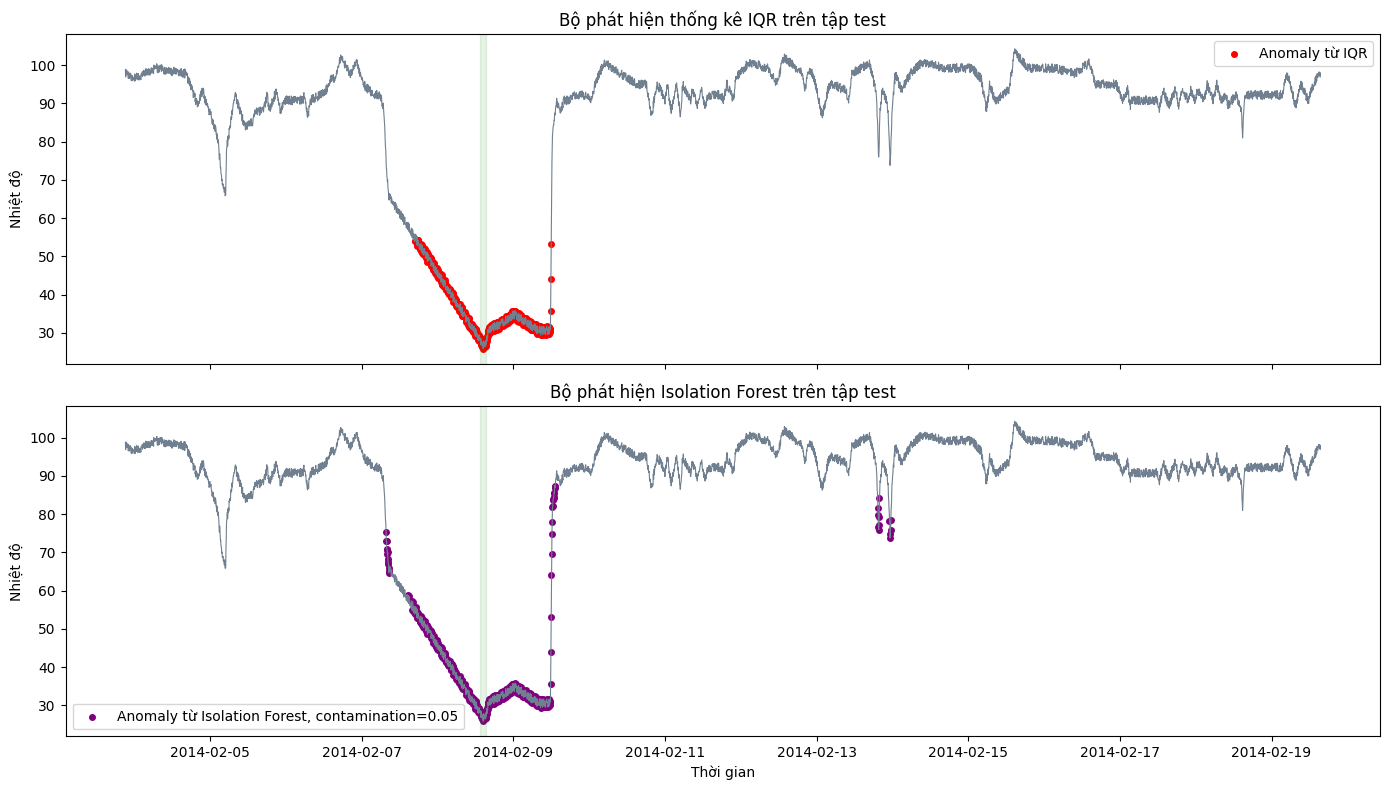

In [13]:
test_plot = df[df["split"] == "test"].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(test_plot["timestamp"], test_plot["value"], color="slategray", linewidth=0.8)
axes[0].scatter(test_plot.loc[test_plot["stat_pred"] == 1, "timestamp"], test_plot.loc[test_plot["stat_pred"] == 1, "value"], s=16, color="red", label="Anomaly từ IQR")
axes[0].set_title("Bộ phát hiện thống kê IQR trên tập test")
axes[0].legend()

axes[1].plot(test_plot["timestamp"], test_plot["value"], color="slategray", linewidth=0.8)
axes[1].scatter(test_plot.loc[test_plot["iforest_pred"] == 1, "timestamp"], test_plot.loc[test_plot["iforest_pred"] == 1, "value"], s=16, color="purple", label=f"Anomaly từ Isolation Forest, contamination={best_contamination}")
axes[1].set_title("Bộ phát hiện Isolation Forest trên tập test")
axes[1].legend()

for ax in axes:
    for ts in anomaly_timestamps:
        if test_plot["timestamp"].min() <= ts <= test_plot["timestamp"].max():
            ax.axvspan(ts - label_window, ts + label_window, color="green", alpha=0.10)
    ax.set_ylabel("Nhiệt độ")
axes[1].set_xlabel("Thời gian")
plt.tight_layout()
plt.show()

## 9. Nhận xét ngắn

Bộ phát hiện thống kê IQR là detector tốt hơn trên tập test trong lần chạy này vì F1 cao hơn Isolation Forest (`0.093` so với `0.086`) và có ít cảnh báo sai hơn. Lý do hợp lý là anomaly trong tập test có dạng giá trị nhiệt độ lệch mạnh, nên một detector dựa trên phân phối như IQR bắt được tín hiệu này khá tốt.

Isolation Forest vẫn hữu ích vì dùng nhiều đặc trưng theo ngữ cảnh như rolling mean/std, lag, giờ trong ngày và rate of change. Tuy nhiên trong bài này, validation cho thấy contamination cao hơn giúp recall tốt hơn nhưng vẫn tạo nhiều cảnh báo sai. Nếu đưa vào production, em sẽ chọn IQR đã tune hệ số trên validation làm baseline chính vì đơn giản, dễ giải thích và có F1 test tốt hơn; đồng thời giữ Isolation Forest để theo dõi thêm khi dữ liệu có anomaly phức tạp hơn.